<a href="https://colab.research.google.com/github/dimkostir/sms_spam_class/blob/main/sms_spam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ανίχνευση Ανεπιθύμητων Μηνυμάτων (SMS Spam Collection)

**Dataset:** SMS Spam Collection (UCI ML Repository)  
Το dataset Που επιλέξαμε θα το βρείτε εδώ: https://archive.ics.uci.edu/dataset/228/sms+spam+collection

**Θα το βρείτε στον φάκελο που σας παραδίδουμε έτσι ώστε όταν τρέξετε το κώδικα να το επιλέξετε απευθείας από εκεί.**

**Στόχος:** Δυαδική ταξινόμηση κειμένων σε *spam* vs *ham* με σύγκριση μοντέλων.



#Ενότητα 1: Φόρτωση Δεδομένων

Σε αυτή την ενότητα φορτώνουμε το σύνολο δεδομένων SMS Spam Collection στο Google Colab, εξετάζουμε τη δομή του (στήλες, πλήθος δειγμάτων και κατηγοριών) και παρουσιάζουμε βασικά στατιστικά στοιχεία που είναι απαραίτητα για την κατανόηση του προβλήματος ταξινόμησης.

In [ ]:
import pandas as pd
from google.colab import files

uploaded = files.upload()  # edw epilegoume to arxeio mas


filename = list(uploaded.keys())[0]
print("Uploaded file:", filename)

df = pd.read_csv(filename, sep="\t", header=None, names=["label", "text"])

df.head()


Saving SMSSpamCollection to SMSSpamCollection (1)
Uploaded file: SMSSpamCollection (1)


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# Περιγραφή δομής αρχείου (πλήθος, στήλες, missing values)

In [ ]:
print("Shape (rows, columns):", df.shape)
print("\nColumns:", df.columns.tolist())

print("\nLabel value counts:")
print(df["label"].value_counts())

print("\nMissing values per column:")
print(df.isna().sum())

print("\nData types / info:")
df.info()


Shape (rows, columns): (5572, 2)

Columns: ['label', 'text']

Label value counts:
label
ham     4825
spam     747
Name: count, dtype: int64

Missing values per column:
label    0
text     0
dtype: int64

Data types / info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5572 non-null   object
 1   text    5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


#Συμπεράσματα Ενότητας 1


1.   Το σύνολο δεδομένων φορτώθηκε επιτυχώς στο Google Colab μέσω upload και    αποθηκεύτηκε σε DataFrame με 5572 δείγματα και 2 στήλες: label και text.
2.   Η στήλη label περιέχει την κατηγορία του μηνύματος (ham ή spam), ενώ η text περιέχει το περιεχόμενο του SMS ως κείμενο.
3.   Δεν υπάρχουν ελλιπείς τιμές (missing values) σε καμία από τις δύο στήλες (0 σε label και 0 σε text), επομένως δεν απαιτείται χειρισμός κενών τιμών.
4. Και οι δύο στήλες έχουν τύπο δεδομένων object, όπως αναμένεται για κατηγορικές τιμές και κείμενο.







#Ενότητα 2: Κατανομή κατηγοριών & ανισορροπία (imbalance).

Σε αυτή την ενότητα εξετάζουμε την κατανομή των κατηγοριών (ham και spam) στο dataset.
Υπολογίζουμε πλήθη και ποσοστά ανά κατηγορία και τα απεικονίζουμε γραφικά, ώστε να εντοπίσουμε πιθανή ανισορροπία κλάσεων, η οποία μπορεί να επηρεάσει την αξιολόγηση των μοντέλων.

In [ ]:
# plithos kai pososta deigmatwn ana katigoria
label_counts = df["label"].value_counts()
label_percent = df["label"].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    "count": label_counts,
    "percent (%)": label_percent.round(2)
})

summary


,count,percent (%)
label,,
ham,4825,86.59
spam,747,13.41


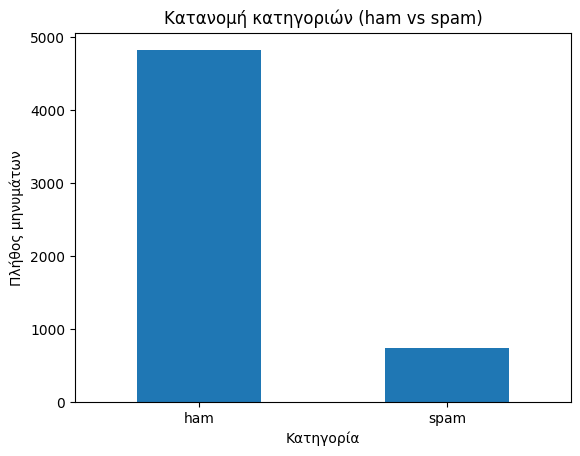

In [ ]:
import matplotlib.pyplot as plt

ax = label_counts.plot(kind="bar")
plt.title("Κατανομή κατηγοριών (ham vs spam)")
plt.xlabel("Κατηγορία")
plt.ylabel("Πλήθος μηνυμάτων")
plt.xticks(rotation=0)


plt.show()


#Συμπεράσματα Ενότητας 2

Παρατηρούμε έντονη ανισορροπία κλάσεων (class imbalance) , καθώς τα ham είναι 4825 (86.59%), ενώ τα spam είναι 747 (13.41%).

Αυτό σημαίνει ότι ένα μοντέλο μπορεί να πετύχει σχετικά υψηλά accuracy ακόμη και αν ευνοεί την πλειοψηφική κλάση (ham), άρα το accuracy από μόνη του δεν είναι αρκετό.

Για πιο αξιόπιστη αξιολόγηση θα δώσουμε έμφαση σε metrics όπως precision, recall και F1-score (ιδιαίτερα για την κλάση spam) και θα χρησιμοποιήσουμε stratified split / cross-validation ώστε να διατηρείται η ίδια αναλογία κλάσεων.

#Ενότητα 3: Μελέτη δείγματος κειμένων

Σε αυτή την ενότητα εξετάζουμε ενδεικτικά μηνύματα από κάθε κατηγορία (ham και spam), ώστε να εντοπίσουμε:


1.   Πιθανά στοιχεία “θορύβου” (URLs, αριθμούς, ειδικούς χαρακτήρες, κεφαλαία κ.λπ.),

2.   Συχνά μοτίβα που χαρακτηρίζουν το spam (π.χ. “free”, “win”, προσφορές, κλήσεις για δράση)

και να τεκμηριώσουμε γιατί απαιτείται καθαρισμός και προεπεξεργασία κειμένου.

In [ ]:
# tha paroume tyxaia deigmata apo kathe katigoria , 5 sygkekrimena apo ti kathe mia
ham_samples = df[df["label"] == "ham"]["text"].sample(5, random_state=42).to_list()
spam_samples = df[df["label"] == "spam"]["text"].sample(5, random_state=42).to_list()

print("=== Δείγματα HAM ===")
for i, msg in enumerate(ham_samples, 1):
    print(f"{i}. {msg}")

print("\n=== Δείγματα SPAM ===")
for i, msg in enumerate(spam_samples, 1):
    print(f"{i}. {msg}")


=== Δείγματα HAM ===
1. If i not meeting ü all rite then i'll go home lor. If ü dun feel like comin it's ok.
2. I.ll always be there, even if its just in spirit. I.ll get a bb soon. Just trying to be sure i need it.
3. Sorry that took so long, omw now
4. I thk 50 shd be ok he said plus minus 10.. Did ü leave a line in between paragraphs?
5. Dunno i juz askin cos i got a card got 20% off 4 a salon called hair sense so i tot it's da one ü cut ur hair. 

=== Δείγματα SPAM ===
1. Summers finally here! Fancy a chat or flirt with sexy singles in yr area? To get MATCHED up just reply SUMMER now. Free 2 Join. OptOut txt STOP Help08714742804
2. This is the 2nd time we have tried 2 contact u. U have won the 750 Pound prize. 2 claim is easy, call 08718726970 NOW! Only 10p per min. BT-national-rate 
3. Get ur 1st RINGTONE FREE NOW! Reply to this msg with TONE. Gr8 TOP 20 tones to your phone every week just £1.50 per wk 2 opt out send STOP 08452810071 16
4. Ur cash-balance is currently 500 pounds -

Έλεγχος για το πόσα μηνύματα περιέχουν URL, τηλέφωνο ή πολλούς αριθμούς, και έντονα κεφαλαία.

In [ ]:
import re

def has_url(text):
    return bool(re.search(r"(http|www\.)", text.lower()))

def has_many_digits(text, min_digits=6):
    #metrame ta synolika psifia poy exei to minima
    return sum(ch.isdigit() for ch in text) >= min_digits

def has_uppercase_emphasis(text, min_upper=10):
    # metraei posa kefalaia exei to minima
    return sum(ch.isupper() for ch in text) >= min_upper

df_tmp = df.copy()
df_tmp["has_url"] = df_tmp["text"].apply(has_url)
df_tmp["has_many_digits"] = df_tmp["text"].apply(has_many_digits)
df_tmp["has_uppercase_emphasis"] = df_tmp["text"].apply(has_uppercase_emphasis)

# ta emfanizoume se pososta ana katigoria
pattern_summary = df_tmp.groupby("label")[["has_url", "has_many_digits", "has_uppercase_emphasis"]].mean() * 100
pattern_summary = pattern_summary.round(2)

pattern_summary


,has_url,has_many_digits,has_uppercase_emphasis
label,,,
ham,0.04,0.81,6.34
spam,14.32,83.00,66.27


#Συμπεράσματα Ενότητας 3

Από τα δείγματα παρατηρούμε ότι τα μηνύματα spam συχνά περιέχουν προσφορές ή υποσχέσεις κέρδους, κλήσεις για ενέργειες από τον χρήστη (Για παράδειγμα “reply”, “text”, “call”), καθώς και αριθμούς ή κωδικούς.

Η ποσοτική ανάλυση επιβεβαιώνει ότι τέτοια μοτίβα εμφανίζονται πολύ συχνότερα στα spam:

1. URLs: ham 0.04% vs spam 14.32%

2. Πολλά ψηφία (≥6): ham 0.81% vs spam 83.00%

3. Έντονα κεφαλαία (≥10): ham 6.34% vs spam 66.27%

Τα παραπάνω δείχνουν ότι το spam έχει πιο θορυβώδη μορφή (πολλοί αριθμοί, κεφαλαία, links), κάτι που καθιστά απαραίτητο τον καθαρισμό κειμένου και την κατάλληλη αναπαράσταση χαρακτηριστικών πριν την εκπαίδευση μοντέλων.

#Ενότητα 4: Καθαρισμός & Προεπεξεργασία Κειμένου

Σε αυτή την ενότητα εφαρμόζουμε καθαρισμό και προεπεξεργασία στα SMS μηνύματα, ώστε να μειώσουμε τον θόρυβο και να κρατήσουμε την πληροφορία που βοηθά την ταξινόμηση. Συγκεκριμένα:

1. Αφαιρούμε URLs και HTML tags,

2. Αφαιρούμε σημεία στίξης και ειδικούς χαρακτήρες,

3. Μετατρέπουμε το κείμενο σε πεζά (lowercase),

3. Αφαιρούμε stopwords

εφαρμόζουμε stemming και lemmatization
και δημιουργούμε ένα νέο πεδίο με το καθαρισμένο κείμενο που θα χρησιμοποιηθεί στα επόμενα βήματα.

In [ ]:
import re
import string
import nltk

nltk.download("stopwords")
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def basic_clean(text: str) -> str:
    # 1) kanoume lowercase
    text = text.lower()
    # 2) afairoume urls
    text = re.sub(r"(http\S+|www\.\S+)", " ", text)
    # 3) afairoume html tags (an yparxoun)
    text = re.sub(r"<.*?>", " ", text)
    # 4) afairoume punctuation/eidikous xaraktires
    text = text.translate(str.maketrans("", "", string.punctuation))
    # 5) kratame mono grammata/arithmous kai kena
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    # 6) afairoume extra kena
    text = re.sub(r"\s+", " ", text).strip()
    # 7) afairoume stopwords
    tokens = [w for w in text.split() if w not in stop_words]
    return " ".join(tokens)

# efarmozoume ton vasiko katharismo
df = df.copy()
df["clean_text"] = df["text"].apply(basic_clean)

# deigmata prin/meta
sample_idx = [0, 2, 4]  # mporeis na allakseis indices an thes
for i in sample_idx:
    print(f"\n--- Sample {i} ({df.loc[i, 'label']}) ---")
    print("ORIGINAL:", df.loc[i, "text"])
    print("CLEANED: ", df.loc[i, "clean_text"])



--- Sample 0 (ham) ---
ORIGINAL: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
CLEANED:  go jurong point crazy available bugis n great world la e buffet cine got amore wat

--- Sample 2 (spam) ---
ORIGINAL: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
CLEANED:  free entry 2 wkly comp win fa cup final tkts 21st may 2005 text fa 87121 receive entry questionstd txt ratetcs apply 08452810075over18s

--- Sample 4 (ham) ---
ORIGINAL: Nah I don't think he goes to usf, he lives around here though
CLEANED:  nah dont think goes usf lives around though


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
import nltk
nltk.download("wordnet")
nltk.download("omw-1.4")

from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text: str) -> str:
    # spame se tokens kai kanoume lemmatization
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

# ftiaxnoume teliko preprocessed kείμενο
df["preprocessed_text"] = df["clean_text"].apply(lemmatize_text)

# deigmata prin/meta (clean -> lemmatized)
sample_idx = [0, 2, 4]
for i in sample_idx:
    print(f"\n--- Sample {i} ({df.loc[i, 'label']}) ---")
    print("CLEANED:     ", df.loc[i, "clean_text"])
    print("LEMMATIZED:  ", df.loc[i, "preprocessed_text"])


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...



--- Sample 0 (ham) ---
CLEANED:      go jurong point crazy available bugis n great world la e buffet cine got amore wat
LEMMATIZED:   go jurong point crazy available bugis n great world la e buffet cine got amore wat

--- Sample 2 (spam) ---
CLEANED:      free entry 2 wkly comp win fa cup final tkts 21st may 2005 text fa 87121 receive entry questionstd txt ratetcs apply 08452810075over18s
LEMMATIZED:   free entry 2 wkly comp win fa cup final tkts 21st may 2005 text fa 87121 receive entry questionstd txt ratetcs apply 08452810075over18s

--- Sample 4 (ham) ---
CLEANED:      nah dont think goes usf lives around though
LEMMATIZED:   nah dont think go usf life around though


Τα **tokens** είναι τα μικρότερα κομμάτια στα οποία σπάμε ένα κείμενο για να το επεξεργαστούμε, συνήθως λέξεις.

Για παράδειγμα, η πρόταση “Free entry in 2 a wkly comp” μπορεί να χωριστεί σε tokens όπως: free, entry, in, 2, a, wkly, comp.

Αυτό το κάνουμε γιατί οι περισσότερες τεχνικές επεξεργασίας φυσικής γλώσσας δουλεύουν λέξη-λέξη, όπως η αφαίρεση stopwords, το stemming και το lemmatization και η μετατροπή του κειμένου σε αριθμητικά χαρακτηριστικά.

Το **lemmatization** είναι μια διαδικασία που μετατρέπει κάθε λέξη στη βασική της μορφή (lemma), δηλαδή στη μορφή που θα έβρισκες στο λεξικό.

Έτσι, λέξεις όπως “cars” γίνονται “car”, “running” γίνεται “run” και “studies” γίνεται “study”.

Με αυτόν τον τρόπο μειώνουμε τις διαφορετικές μορφές της ίδιας λέξης και κρατάμε πιο καθαρή πληροφορία, κάτι που βοηθά ιδιαίτερα σε αναπαραστάσεις όπως Bag-of-Words ή TF-IDF, επειδή μειώνει τον αριθμό των διαφορετικών λέξεων που βλέπει το μοντέλο και κάνει την εκμάθηση πιο σταθερή.

#Συμπεράσματα Ενότητας 4

Στον καθαρισμό κειμένου μετατρέψαμε τα μηνύματα σε πεζά, αφαιρέσαμε URLs και HTML tags (όπου υπάρχουν), σημεία στίξης και ειδικούς χαρακτήρες και κρατήσαμε κυρίως γράμματα και αριθμούς, μειώνοντας έτσι τον θόρυβο.

Αφαιρέσαμε επίσης τα αγγλικά stopwords (όπως για παράδειγμα. “the”, “is”, “to”), ώστε να μην επηρεάζουν την αναπαράσταση του κειμένου λέξεις που εμφανίζονται πολύ συχνά αλλά δεν προσφέρουν ουσιαστική πληροφορία για την ταξινόμηση.

Στη συνέχεια εφαρμόσαμε lemmatization για να φέρουμε λέξεις στη βασική τους μορφή, με στόχο τη μείωση παραλλαγών (όπως για παράδειγμα πληθυντικοί ή κλίσεις) και τη δημιουργία πιο σταθερής αναπαράστασης για τα επόμενα βήματα.

#Ενότητα 5: Εξαγωγή Χαρακτηριστικών με TF-IDF

Σε αυτή την ενότητα μετατρέπουμε το προεπεξεργασμένο κείμενο σε αριθμητικά χαρακτηριστικά, ώστε να μπορεί να χρησιμοποιηθεί από αλγορίθμους μηχανικής μάθησης.
Θα χρησιμοποιήσουμε την αναπαράσταση TF-IDF (Term Frequency – Inverse Document Frequency), η οποία δίνει μεγαλύτερη βαρύτητα σε λέξεις που είναι σημαντικές για ένα μήνυμα αλλά δεν εμφανίζονται υπερβολικά συχνά σε όλα τα μηνύματα. Στη συνέχεια, θα χωρίσουμε τα δεδομένα σε train/test set με stratification, λόγω της ανισορροπίας κλάσεων.

Το TF-IDF είναι ένας τρόπος να βαθμολογούμε τις λέξεις ενός μηνύματος ώστε να ξεχωρίζουμε ποιες είναι πραγματικά χρήσιμες για την ταξινόμηση.

Δίνει μεγαλύτερο βάρος σε μια λέξη όταν:
 (α) εμφανίζεται αρκετά μέσα στο συγκεκριμένο μήνυμα
 (β) δεν εμφανίζεται συχνά σε όλα τα μηνύματα του dataset.

Έτσι, κοινές λέξεις που υπάρχουν παντού (για παράδειγμα “ok”, “the”, “now”) παίρνουν χαμηλή σημασία, ενώ πιο χαρακτηριστικές λέξεις που εμφανίζονται σε λιγότερα μηνύματα (για παράδειγμα “free”, “prize”, “claim”) παίρνουν μεγαλύτερο βάρος.

Με αυτόν τον τρόπο το μοντέλο εστιάζει σε λέξεις που βοηθούν περισσότερο να ξεχωρίσουμε spam από ham.

In [ ]:
from sklearn.model_selection import train_test_split

# metatrepoume ta labels se δυαδική μορφή: spam=1, ham=0
df["y"] = df["label"].map({"ham": 0, "spam": 1})

X = df["preprocessed_text"]
y = df["y"]

# kanoume stratified split logo imbalance
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train_text.shape[0], "Test size:", X_test_text.shape[0])
print("Train class distribution:\n", y_train.value_counts(normalize=True).round(3))
print("Test class distribution:\n", y_test.value_counts(normalize=True).round(3))


Train size: 4457 Test size: 1115
Train class distribution:
 y
0    0.866
1    0.134
Name: proportion, dtype: float64
Test class distribution:
 y
0    0.866
1    0.134
Name: proportion, dtype: float64


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# ftiaxnoume TF-IDF (me unigrams + bigrams gia kalutera apotelesmata)
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# fit mono sto train gia na min exoume data leakage
X_train = tfidf.fit_transform(X_train_text)
X_test  = tfidf.transform(X_test_text)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (4457, 5000)
X_test shape: (1115, 5000)


#Συμπεράσματα Ενότητας 5

Χωρίσαμε το dataset σε σύνολο εκπαίδευσης και ελέγχου με stratified train και test split (80% train, 20% test), ώστε να διατηρηθεί η ίδια αναλογία κατηγοριών (ham και spam) και στα δύο σύνολα, κάτι σημαντικό λόγω της ανισορροπίας κλάσεων.

Στη συνέχεια μετατρέψαμε το προεπεξεργασμένο κείμενο σε αριθμητικά χαρακτηριστικά με TF-IDF, χρησιμοποιώντας unigrams και bigrams και περιορίζοντας το λεξιλόγιο στα 5000 πιο σημαντικά χαρακτηριστικά.

Το αποτέλεσμα είναι ένα διάνυσμα χαρακτηριστικών για κάθε μήνυμα, με διαστάσεις (4457, 5000) για το train και (1115, 5000) για το test, έτοιμο να χρησιμοποιηθεί από μοντέλα μηχανικής μάθησης για ταξινόμηση.

#Ενότητα 6: Δημιουργία & Αξιολόγηση Μοντέλων (Logistic Regression & Naive Bayes)

Σε αυτή την ενότητα εκπαιδεύουμε και αξιολογούμε δύο κλασικά μοντέλα για ταξινόμηση κειμένου, χρησιμοποιώντας ως είσοδο τα TF-IDF χαρακτηριστικά που δημιουργήσαμε στην προηγούμενη ενότητα.

Συγκεκριμένα, θα εφαρμόσουμε:
1. **Logistic Regression** ως ένα ισχυρό baseline γραμμικό μοντέλο
2. **Naive Bayes**  ως μια απλή αλλά ιδιαίτερα αποτελεσματική προσέγγιση.

Στόχος μας είναι να εξετάσουμε πώς αποδίδουν τα δύο μοντέλα στο πρόβλημα διάκρισης spam vs ham, ιδιαίτερα όταν υπάρχει ανισορροπίαα κλάσεων.

Για την αξιολόγηση θα χρησιμοποιήσουμε πολλαπλές μετρικές, όπως:
1. accuracy
2. precision
3. recall
4. F1-score, καθώς και τον πίνακα σύγχυσης (confusion matrix).

Μέσα από τον πίνακα σύγχυσης θα αναλύσουμε αναλυτικά τις περιπτώσεις **True Positives**, **True Negatives**, **False Positives** και **False Negatives**, ώστε να κατανοήσουμε όχι μόνο πόσο καλά αλλά και πώς κάνει λάθη κάθε μοντέλο.
(Για παράδειγμα πόσα ham χαρακτηρίστηκαν λανθασμένα ως spam ή πόσα spam πέρασαν ως ham).

Τέλος, θα κάνουμε συγκριτική παρουσίαση των δύο μοντέλων, ώστε να επιλέξουμε την καταλληλότερη προσέγγιση με βάση τόσο τις μετρικές όσο και το είδος των σφαλμάτων.

###Logistic Regression (train + predictions)

In [ ]:
from sklearn.linear_model import LogisticRegression

# ekpaideuoume Logistic Regression (baseline)
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# provlepseis sto test set
y_pred_lr = log_reg.predict(X_test)

print("Logistic Regression: done")


Logistic Regression: done


### Confusion Matrix Για Logistic Regression

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import pandas as pd

# metrics
acc = accuracy_score(y_test, y_pred_lr)
prec = precision_score(y_test, y_pred_lr)
rec = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)

print("=== Logistic Regression Metrics ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

# confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)  # [[TN, FP],[FN, TP]]
tn, fp, fn, tp = cm.ravel()

cm_df = pd.DataFrame(
    cm,
    index=["Actual ham (0)", "Actual spam (1)"],
    columns=["Pred ham (0)", "Pred spam (1)"]
)

print("\n=== Confusion Matrix (Logistic Regression) ===")
display(cm_df)

print("\n=== TP/TN/FP/FN (Logistic Regression) ===")
print(f"TN (True Negatives) : {tn}")
print(f"FP (False Positives): {fp}")
print(f"FN (False Negatives): {fn}")
print(f"TP (True Positives) : {tp}")

print("\n=== Classification Report (Logistic Regression) ===")
print(classification_report(y_test, y_pred_lr, target_names=["ham", "spam"]))


=== Logistic Regression Metrics ===
Accuracy : 0.9695
Precision: 1.0000
Recall   : 0.7718
F1-score : 0.8712

=== Confusion Matrix (Logistic Regression) ===


,Pred ham (0),Pred spam (1)
Actual ham (0),966,0
Actual spam (1),34,115



=== TP/TN/FP/FN (Logistic Regression) ===
TN (True Negatives) : 966
FP (False Positives): 0
FN (False Negatives): 34
TP (True Positives) : 115

=== Classification Report (Logistic Regression) ===
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       1.00      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



### Naive Bayes (train + predictions)

In [ ]:
from sklearn.naive_bayes import MultinomialNB

# ekpaideuoume Naive Bayes
nb = MultinomialNB()
nb.fit(X_train, y_train)

# provlepseis sto test set
y_pred_nb = nb.predict(X_test)

print("Naive Bayes: done")


Naive Bayes: done


### Confusion Matrix (Naive Bayes)

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import pandas as pd

# metrics
acc_nb = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb)
rec_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print("=== Naive Bayes Metrics ===")
print(f"Accuracy : {acc_nb:.4f}")
print(f"Precision: {prec_nb:.4f}")
print(f"Recall   : {rec_nb:.4f}")
print(f"F1-score : {f1_nb:.4f}")

# confusion matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)  # [[TN, FP],[FN, TP]]
tn_nb, fp_nb, fn_nb, tp_nb = cm_nb.ravel()

cm_nb_df = pd.DataFrame(
    cm_nb,
    index=["Actual ham (0)", "Actual spam (1)"],
    columns=["Pred ham (0)", "Pred spam (1)"]
)

print("\n=== Confusion Matrix (Naive Bayes) ===")
display(cm_nb_df)

print("\n=== TP/TN/FP/FN (Naive Bayes) ===")
print(f"TN (True Negatives) : {tn_nb}")
print(f"FP (False Positives): {fp_nb}")
print(f"FN (False Negatives): {fn_nb}")
print(f"TP (True Positives) : {tp_nb}")

print("\n=== Classification Report (Naive Bayes) ===")
print(classification_report(y_test, y_pred_nb, target_names=["ham", "spam"]))


=== Naive Bayes Metrics ===
Accuracy : 0.9722
Precision: 1.0000
Recall   : 0.7919
F1-score : 0.8839

=== Confusion Matrix (Naive Bayes) ===


,Pred ham (0),Pred spam (1)
Actual ham (0),966,0
Actual spam (1),31,118



=== TP/TN/FP/FN (Naive Bayes) ===
TN (True Negatives) : 966
FP (False Positives): 0
FN (False Negatives): 31
TP (True Positives) : 118

=== Classification Report (Naive Bayes) ===
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       1.00      0.79      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115



#Σύγκριση των 2 Μοντέλων

In [ ]:
import pandas as pd

comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": acc,
        "Precision(spam)": prec,
        "Recall(spam)": rec,
        "F1(spam)": f1,
        "TN": tn, "FP": fp, "FN": fn, "TP": tp
    },
    {
        "Model": "Naive Bayes",
        "Accuracy": acc_nb,
        "Precision(spam)": prec_nb,
        "Recall(spam)": rec_nb,
        "F1(spam)": f1_nb,
        "TN": tn_nb, "FP": fp_nb, "FN": fn_nb, "TP": tp_nb
    }
])

comparison


,Model,Accuracy,Precision(spam),Recall(spam),F1(spam),TN,FP,FN,TP
0,Logistic Regression,0.969507,1.0,0.771812,0.871212,966,0,34,115
1,Naive Bayes,0.972197,1.0,0.791946,0.883895,966,0,31,118


#Συμπεράσματα ενότητας 6

Στην ενότητα αυτή συγκρίναμε δύο βασικά μοντέλα ταξινόμησης κειμένου πάνω στα ίδια TF-IDF χαρακτηριστικά:
1. Logistic Regression
2. Naive Bayes.

Η αξιολόγηση έγινε στο ίδιο test set και περιλάμβανε τόσο συνολικές μετρικές (accuracy, precision, recall, F1) όσο και ανάλυση των σφαλμάτων μέσω του πίνακα σύγχυσης (TN, FP, FN, TP), ώστε να κατανοήσουμε όχι μόνο πόσο καλά αποδίδουν τα μοντέλα αλλά και τι είδους λάθη κάνουν.

Και τα δύο μοντέλα εμφάνισαν πολύ υψηλή απόδοση.

Η **Logistic Regression** πέτυχε accuracy περίπου 0.9695, ενώ το **Naive Bayes** περίπου 0.9722.

Η διαφορά είναι μικρή, αλλά υπαρκτή, και δείχνει ότι και οι δύο προσεγγίσεις είναι κατάλληλες για το συγκεκριμένο dataset.

Ακόμη πιο σημαντικό, και στα δύο μοντέλα η precision για την κλάση spam είναι 1.0.

Αυτό σημαίνει ότι όταν το μοντέλο χαρακτηρίζει ένα μήνυμα ως spam, είναι πράγματι spam — επιβεβαιώνεται και από το γεγονός ότι έχουμε False Positives = 0 και στα δύο (δηλαδή κανένα ham δεν χαρακτηρίστηκε λανθασμένα ως spam).

Πρακτικά, αυτό είναι πολύ θετικό, γιατί μειώνει τον κίνδυνο να χαθούν κανονικά μηνύματα.

Η κύρια διαφορά των μοντέλων εμφανίζεται στην ικανότητα εντοπισμού spam, δηλαδή στο recall της κλάσης spam και στα False Negatives (FN).

Η **Logistic Regression** είχε recall(spam)=0.7718 με FN=34.

Tο **Naive Bayes** είχε recall(spam)=0.7919 με FN=31.

Με απλά λόγια, το Naive Bayes πιάνει λίγο περισσότερα spam και αφήνει λιγότερα να περάσουν ως ham.

Αυτό φαίνεται και στο F1-score(spam), που είναι υψηλότερο στο Naive Bayes (0.8839 έναντι 0.8712), άρα συνολικά ισορροπεί καλύτερα ανάμεσα σε precision και recall για την κλάση spam.

Συνολικά, καταλήγουμε ότι το **Naive Bayes** είναι ελαφρώς καλύτερη επιλογή για το συγκεκριμένο πρόβλημα και τα συγκεκριμένα χαρακτηριστικά, καθώς διατηρεί το ίδιο άριστο επίπεδο αποφυγής ψευδών συναγερμών (FP=0), αλλά ταυτόχρονα μειώνει τα spam που ξεφεύγουν (μικρότερο FN) και πετυχαίνει ελαφρώς καλύτερο recall/F1.

Παρ’ όλα αυτά, και τα δύο μοντέλα μπορούν να θεωρηθούν πολύ ισχυρά baselines, και η τελική επιλογή εξαρτάται από το τι μας ενδιαφέρει περισσότερο.

Eδώ, επειδή θέλουμε να εντοπίζουμε όσο το δυνατόν περισσότερα spam χωρίς να μπλοκάρουμε ham, το **Naive Bayes** δίνει την καλύτερη ισορροπία στα αποτελέσματά μας.

#Ενότητα 7: Προχωρημένα Μοντέλα — Random Forest και XGBoost

Σε αυτή την ενότητα θα εφαρμόσουμε δύο πιο προχωρημένες μεθόδους για ταξινόμηση κειμένου πάνω στα TF-IDF χαρακτηριστικά: **Random Forest** και **XGBoost**.

Στόχος είναι να δούμε αν μοντέλα που συνδυάζουν πολλά απλά μοντέλα μπορούν να βελτιώσουν την απόδοση σε σχέση με τα βασικά μοντέλα που δοκιμάσαμε (Logistic Regression και Naive Bayes), ιδιαίτερα ως προς την ανίχνευση spam.



1.   Το μοντέλο **Random Forest** αποτελείται από πολλά decision trees. Κάθε δέντρο εκπαιδεύεται σε διαφορετικό τυχαίο υποσύνολο των δεδομένων (bootstrap sampling) και σε τυχαίο υποσύνολο χαρακτηριστικών, και στο τέλος η τελική πρόβλεψη προκύπτει με “ψηφοφορία” των δέντρων.
Η τυχαιότητα αυτή μειώνει το overfitting ενός μεμονωμένου δέντρου και συνήθως οδηγεί σε πιο σταθερή απόδοση.

2. Το μοντέλο **XGBoost (Extreme Gradient Boosting)** είναι μια μέθοδος boosting, όπου εκπαιδεύουμε διαδοχικά πολλά αδύναμα δέντρα, αλλά κάθε νέο δέντρο προσπαθεί να διορθώσει τα λάθη των προηγούμενων.

Με αυτόν τον τρόπο, το μοντέλο βελτιώνεται σταδιακά, δίνοντας έμφαση στις δύσκολες περιπτώσεις ταξινόμησης.
Το XGBoost είναι ιδιαίτερα δημοφιλές επειδή είναι αποδοτικό, έχει ισχυρούς μηχανισμούς regularization και συχνά πετυχαίνει πολύ υψηλή απόδοση.

##Random Forest (train + predictions)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# ekpaideuoume Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest: done")


Random Forest: done


In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import pandas as pd

# metrics
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("=== Random Forest Metrics ===")
print(f"Accuracy : {acc_rf:.4f}")
print(f"Precision: {prec_rf:.4f}")
print(f"Recall   : {rec_rf:.4f}")
print(f"F1-score : {f1_rf:.4f}")

# confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)  # [[TN, FP],[FN, TP]]
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()

cm_rf_df = pd.DataFrame(
    cm_rf,
    index=["Actual ham (0)", "Actual spam (1)"],
    columns=["Pred ham (0)", "Pred spam (1)"]
)

print("\n=== Confusion Matrix (Random Forest) ===")
display(cm_rf_df)

print("\n=== TP/TN/FP/FN (Random Forest) ===")
print(f"TN (True Negatives) : {tn_rf}")
print(f"FP (False Positives): {fp_rf}")
print(f"FN (False Negatives): {fn_rf}")
print(f"TP (True Positives) : {tp_rf}")

print("\n=== Classification Report (Random Forest) ===")
print(classification_report(y_test, y_pred_rf, target_names=["ham", "spam"]))


=== Random Forest Metrics ===
Accuracy : 0.9767
Precision: 1.0000
Recall   : 0.8255
F1-score : 0.9044

=== Confusion Matrix (Random Forest) ===


,Pred ham (0),Pred spam (1)
Actual ham (0),966,0
Actual spam (1),26,123



=== TP/TN/FP/FN (Random Forest) ===
TN (True Negatives) : 966
FP (False Positives): 0
FN (False Negatives): 26
TP (True Positives) : 123

=== Classification Report (Random Forest) ===
              precision    recall  f1-score   support

         ham       0.97      1.00      0.99       966
        spam       1.00      0.83      0.90       149

    accuracy                           0.98      1115
   macro avg       0.99      0.91      0.95      1115
weighted avg       0.98      0.98      0.98      1115



## XGBoost (train + predictions)

In [ ]:
# install xgboost
!pip -q install xgboost

from xgboost import XGBClassifier

# ekpaideuoume XGBoost
xgb = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost: done")


XGBoost: done


In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import pandas as pd

# metrics
acc_xgb = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
rec_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print("=== XGBoost Metrics ===")
print(f"Accuracy : {acc_xgb:.4f}")
print(f"Precision: {prec_xgb:.4f}")
print(f"Recall   : {rec_xgb:.4f}")
print(f"F1-score : {f1_xgb:.4f}")

# confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)  # [[TN, FP],[FN, TP]]
tn_xgb, fp_xgb, fn_xgb, tp_xgb = cm_xgb.ravel()

cm_xgb_df = pd.DataFrame(
    cm_xgb,
    index=["Actual ham (0)", "Actual spam (1)"],
    columns=["Pred ham (0)", "Pred spam (1)"]
)

print("\n=== Confusion Matrix (XGBoost) ===")
display(cm_xgb_df)

print("\n=== TP/TN/FP/FN (XGBoost) ===")
print(f"TN (True Negatives) : {tn_xgb}")
print(f"FP (False Positives): {fp_xgb}")
print(f"FN (False Negatives): {fn_xgb}")
print(f"TP (True Positives) : {tp_xgb}")

print("\n=== Classification Report (XGBoost) ===")
print(classification_report(y_test, y_pred_xgb, target_names=["ham", "spam"]))


=== XGBoost Metrics ===
Accuracy : 0.9695
Precision: 0.9259
Recall   : 0.8389
F1-score : 0.8803

=== Confusion Matrix (XGBoost) ===


,Pred ham (0),Pred spam (1)
Actual ham (0),956,10
Actual spam (1),24,125



=== TP/TN/FP/FN (XGBoost) ===
TN (True Negatives) : 956
FP (False Positives): 10
FN (False Negatives): 24
TP (True Positives) : 125

=== Classification Report (XGBoost) ===
              precision    recall  f1-score   support

         ham       0.98      0.99      0.98       966
        spam       0.93      0.84      0.88       149

    accuracy                           0.97      1115
   macro avg       0.95      0.91      0.93      1115
weighted avg       0.97      0.97      0.97      1115



# Πίνακας σύγκρισης Random Forest και XGBoost

In [ ]:
import pandas as pd

adv_comparison = pd.DataFrame([
    {
        "Model": "Random Forest",
        "Accuracy": acc_rf,
        "Precision(spam)": prec_rf,
        "Recall(spam)": rec_rf,
        "F1(spam)": f1_rf,
        "TN": tn_rf, "FP": fp_rf, "FN": fn_rf, "TP": tp_rf
    },
    {
        "Model": "XGBoost",
        "Accuracy": acc_xgb,
        "Precision(spam)": prec_xgb,
        "Recall(spam)": rec_xgb,
        "F1(spam)": f1_xgb,
        "TN": tn_xgb, "FP": fp_xgb, "FN": fn_xgb, "TP": tp_xgb
    }
])

adv_comparison


,Model,Accuracy,Precision(spam),Recall(spam),F1(spam),TN,FP,FN,TP
0,Random Forest,0.976682,1.000000,0.825503,0.904412,966,0,26,123
1,XGBoost,0.969507,0.925926,0.838926,0.880282,956,10,24,125


#Συμπεράσματα ενότητας 7


Στην ενότητα 7 εφαρμόσαμε δύο προχωρημένα μοντέλα , **Random Forest** και **XGBoost**, πάνω στα TF-IDF χαρακτηριστικά, με στόχο να εξετάσουμε αν οι  μέθοδοι αυτοί μπορούν να βελτιώσουν την ανίχνευση spam σε σχέση με τα βασικά μοντέλα.

Και τα δύο μοντέλα πέτυχαν υψηλή συνολική απόδοση, ωστόσο η συμπεριφορά τους διαφέρει αισθητά ως προς το είδος των λαθών που κάνουν, κάτι που είναι κρίσιμο σε εφαρμογές φιλτραρίσματος ανεπιθύμητων μηνυμάτων.

1. Η μέθοδος **Random Forest** παρουσίασε την καλύτερη συνολική εικόνα:
* Πέτυχε accuracy 0.9767
* Ιδιαίτερα υψηλό F1(spam)  0.9044
* Και διατήρησε precision(spam)=1.0

Το σημαντικότερο εύρημα είναι ότι είχε FP=0, δηλαδή δεν χαρακτήρισε κανένα ham ως spam.
Παράλληλα, εντόπισε 123 spam (TP=123) και άφησε να ξεφύγουν 26 spam (FN=26). Αυτό σημαίνει ότι είναι ένα **ασφαλές μοντέλο**, αφού αποφεύγει πλήρως τα ψευδώς θετικά, διατηρώντας ταυτόχρονα πολύ καλή ικανότητα ανίχνευσης spam.

2. Η μέθοδος **XGBoost** εμφάνισε:
* Recall(spam) 0.8389, ελαφρώς υψηλότερο από του Random Forest. Αυτό σημαίνει ότι έπιασε λίγο περισσότερα spam (TP=125 και FN=24).

Ωστόσο, αυτό επιτεύχθηκε με κόστος στη συγκεκριμενοποίηση των προβλέψεων καθώς: * Το precision μειώθηκε σε  0.9259 και
* Εμφανίστηκαν FP=10 (10 ham χαρακτηρίστηκαν λανθασμένα ως spam).

Παρότι το μοντέλο βρίσκει οριακά περισσότερα spam, κάνει περισσότερους ψευδείς συναγερμούς, κάτι που σε πραγματικές συνθήκες μπορεί να είναι ανεπιθύμητο, επειδή οδηγεί σε απόρριψη κανονικών μηνυμάτων.

**Συνολικά**, καταλήγουμε ότι για το συγκεκριμένο dataset και με κριτήριο την ισορροπία μεταξύ απόδοσης και κόστους λαθών, **ο Random Forest υπερέχει καθώς:**

1. Προσφέρει πολύ υψηλή συνολική ακρίβεια
2. Το υψηλότερο F1 για spam
3. Και κυρίως μηδενικά false positives, που είναι ιδιαίτερα σημαντικό σε συστήματα spam filtering.

Το **XGBoost** αποτελεί επίσης ισχυρή επιλογή όταν προτεραιότητα είναι να μειώσουμε όσο γίνεται τα spam που ξεφεύγουν (FN), αλλά στην παρούσα ρύθμιση αυτό συνοδεύεται από αύξηση ψευδώς θετικών, άρα απαιτεί περαιτέρω ρύθμιση αν θέλουμε να μειωθούν οι ανακατατάξεις σε ham μηνύματα.

# Ενότητα 8: Πειραματισμός με Deep Learning (LSTM)

Σε αυτή την ενότητα θα πειραματιστούμε με ένα μοντέλο deep learning, συγκεκριμένα ένα LSTM (Long Short-Term Memory), το οποίο είναι κατάλληλο για ακολουθιακά δεδομένα όπως το κείμενο. Σε αντίθεση με τα προηγούμενα μοντέλα που βασίζονται σε TF-IDF (δηλαδή μετρήσεις λέξεων και φράσεων χωρίς σειρά), ένα LSTM επεξεργάζεται το κείμενο ως σειρά tokens και μπορεί να αξιοποιήσει πληροφορία από τη σειρά και το πλαίσιο των λέξεων.

Στόχος μας είναι να δούμε αν ένα νευρωνικό μοντέλο μπορεί να βελτιώσει την ανίχνευση spam και πώς συγκρίνεται με τις κλασικές μεθόδους.

###Προετοιμασία δεδομένων για LSTM (tokenization + padding)

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# orizoume keimeno eisodou (xrisimopoioume to clean_text gia na min exoume polu thorivo)
texts = df["clean_text"].astype(str).values
labels = df["y"].values

max_words = 10000   # megisto lexilogio
max_len = 100       # megisto mikos minimatos (se tokens)

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)
X_seq = pad_sequences(sequences, maxlen=max_len, padding="post", truncating="post")

print("X_seq shape:", X_seq.shape)
print("Example sequence:", X_seq[0][:20])


X_seq shape: (5572, 100)
Example sequence: [  10 4211  683  604  572 1130   38   58  268 1131   81 2754 1132   16
 4212   68    0    0    0    0]


###Train/Test split για sequences (με stratify)

In [ ]:
from sklearn.model_selection import train_test_split

# kanoume stratified split logo imbalance
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq, labels, test_size=0.2, random_state=42, stratify=labels
)

print("Train seq shape:", X_train_seq.shape, "Test seq shape:", X_test_seq.shape)
print("Train class distribution:\n", pd.Series(y_train_seq).value_counts(normalize=True).round(3))
print("Test class distribution:\n", pd.Series(y_test_seq).value_counts(normalize=True).round(3))


Train seq shape: (4457, 100) Test seq shape: (1115, 100)
Train class distribution:
 0    0.866
1    0.134
Name: proportion, dtype: float64
Test class distribution:
 0    0.866
1    0.134
Name: proportion, dtype: float64


###Ορισμός και εκπαίδευση LSTM

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# orizoume to LSTM modelo
embedding_dim = 64

model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# early stopping gia na min kanoume overfitting
early_stop = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

history = model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=5,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 17s 225ms/step - accuracy: 0.8508 - loss: 0.4691 - val_accuracy: 0.8430 - val_loss: 0.4358
Epoch 2/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 12s 212ms/step - accuracy: 0.8781 - loss: 0.3754 - val_accuracy: 0.8430 - val_loss: 0.4380
Epoch 3/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 159ms/step - accuracy: 0.8789 - loss: 0.3740 - val_accuracy: 0.8430 - val_loss: 0.4412


###Αξιολόγηση LSTM (metrics + confusion matrix + TP/TN/FP/FN)

In [ ]:
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import pandas as pd

# kanoume provlepseis (probabilities) kai tis metatrepoume se 0/1 me threshold 0.5
y_prob_lstm = model.predict(X_test_seq).ravel()
y_pred_lstm = (y_prob_lstm >= 0.5).astype(int)

# metrics
acc_lstm = accuracy_score(y_test_seq, y_pred_lstm)
prec_lstm = precision_score(y_test_seq, y_pred_lstm)
rec_lstm = recall_score(y_test_seq, y_pred_lstm)
f1_lstm = f1_score(y_test_seq, y_pred_lstm)

print("=== LSTM Metrics ===")
print(f"Accuracy : {acc_lstm:.4f}")
print(f"Precision: {prec_lstm:.4f}")
print(f"Recall   : {rec_lstm:.4f}")
print(f"F1-score : {f1_lstm:.4f}")

# confusion matrix
cm_lstm = confusion_matrix(y_test_seq, y_pred_lstm)  # [[TN, FP],[FN, TP]]
tn_lstm, fp_lstm, fn_lstm, tp_lstm = cm_lstm.ravel()

cm_lstm_df = pd.DataFrame(
    cm_lstm,
    index=["Actual ham (0)", "Actual spam (1)"],
    columns=["Pred ham (0)", "Pred spam (1)"]
)

print("\n=== Confusion Matrix (LSTM) ===")
display(cm_lstm_df)

print("\n=== TP/TN/FP/FN (LSTM) ===")
print(f"TN (True Negatives) : {tn_lstm}")
print(f"FP (False Positives): {fp_lstm}")
print(f"FN (False Negatives): {fn_lstm}")
print(f"TP (True Positives) : {tp_lstm}")

print("\n=== Classification Report (LSTM) ===")
print(classification_report(y_test_seq, y_pred_lstm, target_names=["ham", "spam"]))


35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
=== LSTM Metrics ===
Accuracy : 0.8664
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000

=== Confusion Matrix (LSTM) ===


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Pred ham (0),Pred spam (1)
Actual ham (0),966,0
Actual spam (1),149,0



=== TP/TN/FP/FN (LSTM) ===
TN (True Negatives) : 966
FP (False Positives): 0
FN (False Negatives): 149
TP (True Positives) : 0

=== Classification Report (LSTM) ===
              precision    recall  f1-score   support

         ham       0.87      1.00      0.93       966
        spam       0.00      0.00      0.00       149

    accuracy                           0.87      1115
   macro avg       0.43      0.50      0.46      1115
weighted avg       0.75      0.87      0.80      1115



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Τα αποτελέσματα δείχνουν ότι το LSTM έχει κολλήσει στην πλειοψηφική κλάση (ham) και ουσιαστικά δεν προβλέπει ποτέ spam.
Αυτό συμβαίνει συχνά σε datasets με ανισορροπία κλάσεων, επειδή τα ham είναι πολύ περισσότερα, το μοντέλο μπορεί να πετύχει σχετικά υψηλό accuracy απλώς προβλέποντας “ham” για όλα, αλλά στην πράξη αποτυγχάνει στον πραγματικό στόχο μας που είναι να εντοπίζουμε spam.

Για να διορθώσουμε αυτή τη συμπεριφορά, χρησιμοποιούμε class weights, δηλαδή δίνουμε μεγαλύτερο βάρος στα λάθη πάνω στην κλάση spam. Έτσι το μοντέλο αναγκάζεται να δώσει περισσότερη προσοχή στα spam δείγματα κατά την εκπαίδευση και να μάθει μοτίβα που τα διαχωρίζουν από τα ham.

###Class Weights για να μάθει και το spam

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# ypologizoume class weights gia na dosoume perissoteri varutita sto spam
classes = np.array([0, 1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_seq)
class_weight = {0: weights[0], 1: weights[1]}

print("Class weights:", class_weight)


Class weights: {0: np.float64(0.577481212749417), 1: np.float64(3.7265886287625416)}


###Εκπαιδεύουμε ξανά το LSTM με class_weight

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ksanaxtizουμε to modelo (kalytera na min synexisei apo palies varos)
embedding_dim = 64

model_w = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim),
    LSTM(64),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model_w.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

history_w = model_w.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=8,
    batch_size=64,
    callbacks=[early_stop],
    class_weight=class_weight,   # edw vazoume ta weights
    verbose=1
)


Epoch 1/8
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - accuracy: 0.6799 - loss: 0.6758 - val_accuracy: 0.8430 - val_loss: 0.6806
Epoch 2/8
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 0.8331 - loss: 0.6764 - val_accuracy: 0.8430 - val_loss: 0.6796
Epoch 3/8
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 0.6960 - loss: 0.6941 - val_accuracy: 0.8430 - val_loss: 0.6644
Epoch 4/8
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - accuracy: 0.8330 - loss: 0.6857 - val_accuracy: 0.8430 - val_loss: 0.6813
Epoch 5/8
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.8402 - loss: 0.6507 - val_accuracy: 0.1570 - val_loss: 0.6947


###Αξιολόγηση του LSTM με class weights (model_w)

In [ ]:
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import pandas as pd

# provlepseis apo to neo modelo
y_prob_lstm_w = model_w.predict(X_test_seq).ravel()
y_pred_lstm_w = (y_prob_lstm_w >= 0.5).astype(int)

# metrics
acc_lstm_w = accuracy_score(y_test_seq, y_pred_lstm_w)
prec_lstm_w = precision_score(y_test_seq, y_pred_lstm_w, zero_division=0)
rec_lstm_w = recall_score(y_test_seq, y_pred_lstm_w, zero_division=0)
f1_lstm_w = f1_score(y_test_seq, y_pred_lstm_w, zero_division=0)

print("=== LSTM (with class weights) Metrics ===")
print(f"Accuracy : {acc_lstm_w:.4f}")
print(f"Precision: {prec_lstm_w:.4f}")
print(f"Recall   : {rec_lstm_w:.4f}")
print(f"F1-score : {f1_lstm_w:.4f}")

# confusion matrix
cm_lstm_w = confusion_matrix(y_test_seq, y_pred_lstm_w)  # [[TN, FP],[FN, TP]]
tn_lstm_w, fp_lstm_w, fn_lstm_w, tp_lstm_w = cm_lstm_w.ravel()

cm_lstm_w_df = pd.DataFrame(
    cm_lstm_w,
    index=["Actual ham (0)", "Actual spam (1)"],
    columns=["Pred ham (0)", "Pred spam (1)"]
)

print("\n=== Confusion Matrix (LSTM with class weights) ===")
display(cm_lstm_w_df)

print("\n=== TP/TN/FP/FN (LSTM with class weights) ===")
print(f"TN (True Negatives) : {tn_lstm_w}")
print(f"FP (False Positives): {fp_lstm_w}")
print(f"FN (False Negatives): {fn_lstm_w}")
print(f"TP (True Positives) : {tp_lstm_w}")

print("\n=== Classification Report (LSTM with class weights) ===")
print(classification_report(y_test_seq, y_pred_lstm_w, target_names=["ham", "spam"], zero_division=0))


35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
=== LSTM (with class weights) Metrics ===
Accuracy : 0.8664
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000

=== Confusion Matrix (LSTM with class weights) ===


,Pred ham (0),Pred spam (1)
Actual ham (0),966,0
Actual spam (1),149,0



=== TP/TN/FP/FN (LSTM with class weights) ===
TN (True Negatives) : 966
FP (False Positives): 0
FN (False Negatives): 149
TP (True Positives) : 0

=== Classification Report (LSTM with class weights) ===
              precision    recall  f1-score   support

         ham       0.87      1.00      0.93       966
        spam       0.00      0.00      0.00       149

    accuracy                           0.87      1115
   macro avg       0.43      0.50      0.46      1115
weighted avg       0.75      0.87      0.80      1115



#Συμπεράσματα ενότητας 8


Στην ενότητα 8 δοκιμάσαμε ένα μοντέλο deep learning το LSTM, το οποίο σε θεωρητικό επίπεδο μπορεί να αξιοποιήσει τη σειριακή δομή του κειμένου (σε αντίθεση με το TF-IDF).

Ωστόσο, στην πράξη το μοντέλο κατέρρευσε στην πλειοψηφική κλάση:
τόσο πριν όσο και μετά τη χρήση class weights, κατέληξε να προβλέπει όλα τα μηνύματα ως ham.

Αυτό φαίνεται καθαρά από τον πίνακα σύγχυσης, όπου έχουμε TN=966, TP=0, FP=0, FN=149, άρα precision/recall/F1 για την κλάση spam είναι 0.

Παρότι το accuracy παραμένει περίπου 0.866, αυτή η τιμή είναι παραπλανητική λόγω του imbalanced dataset, αφού το μοντέλο ουσιαστικά δεν επιτυγχάνει τον πραγματικό στόχο (εντοπισμό spam).

**Συνεπώς, για το συγκεκριμένο dataset και με αυτή την απλή ρύθμιση, το LSTM δεν είναι κατάλληλο και υστερεί σημαντικά έναντι των κλασικών και ensemble μοντέλων (Logistic Regression, Naive Bayes, Random Forest, XGBoost), τα οποία πέτυχαν υψηλή ανίχνευση spam και σαφώς καλύτερες μετρικές.**

#Ενότητα 9: Cross-Validation και Τελική Συγκριτική Παρουσίαση Μοντέλων

## 1. Cross-validation για Logistic Regression και Naive Bayes



In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
import pandas as pd

X_text_all = df["preprocessed_text"]
y_all = df["y"]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

# Logistic Regression pipeline
pipe_lr = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

# Naive Bayes pipeline
pipe_nb = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ("clf", MultinomialNB())
])

results_lr = cross_validate(pipe_lr, X_text_all, y_all, cv=cv, scoring=scoring)
results_nb = cross_validate(pipe_nb, X_text_all, y_all, cv=cv, scoring=scoring)

def summarize_cv(results, model_name):
    return {
        "Model": model_name,
        "Accuracy (mean)": results["test_accuracy"].mean(),
        "Accuracy (std)": results["test_accuracy"].std(),
        "Precision (mean)": results["test_precision"].mean(),
        "Precision (std)": results["test_precision"].std(),
        "Recall (mean)": results["test_recall"].mean(),
        "Recall (std)": results["test_recall"].std(),
        "F1 (mean)": results["test_f1"].mean(),
        "F1 (std)": results["test_f1"].std(),
    }

cv_summary = pd.DataFrame([
    summarize_cv(results_lr, "Logistic Regression"),
    summarize_cv(results_nb, "Naive Bayes")
])

cv_summary


,Model,Accuracy (mean),Accuracy (std),Precision (mean),Precision (std),Recall (mean),Recall (std),F1 (mean),F1 (std)
0,Logistic Regression,0.963747,0.003339,0.977134,0.009267,0.746989,0.019607,0.846616,0.015456
1,Naive Bayes,0.971105,0.003285,0.996565,0.004209,0.787114,0.022894,0.879383,0.015237


## 2. Cross-Validation για Random Forest και XGBoost

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# an den einai idi installed to xgboost apo prin, den peirazei na to ksana kanoume
!pip -q install xgboost
from xgboost import XGBClassifier

X_text_all = df["preprocessed_text"]
y_all = df["y"]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

# Random Forest pipeline
pipe_rf = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

# XGBoost pipeline
pipe_xgb = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ("clf", XGBClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    ))
])

results_rf = cross_validate(pipe_rf, X_text_all, y_all, cv=cv, scoring=scoring)
results_xgb = cross_validate(pipe_xgb, X_text_all, y_all, cv=cv, scoring=scoring)

def summarize_cv(results, model_name):
    return {
        "Model": model_name,
        "Accuracy (mean)": results["test_accuracy"].mean(),
        "Accuracy (std)": results["test_accuracy"].std(),
        "Precision (mean)": results["test_precision"].mean(),
        "Precision (std)": results["test_precision"].std(),
        "Recall (mean)": results["test_recall"].mean(),
        "Recall (std)": results["test_recall"].std(),
        "F1 (mean)": results["test_f1"].mean(),
        "F1 (std)": results["test_f1"].std(),
    }

cv_summary_adv = pd.DataFrame([
    summarize_cv(results_rf, "Random Forest"),
    summarize_cv(results_xgb, "XGBoost")
])

cv_summary_adv


,Model,Accuracy (mean),Accuracy (std),Precision (mean),Precision (std),Recall (mean),Recall (std),F1 (mean),F1 (std)
0,Random Forest,0.977027,0.001854,0.996923,0.006154,0.831284,0.017019,0.906460,0.008725
1,XGBoost,0.971104,0.004902,0.956659,0.025600,0.821933,0.017495,0.884109,0.019397


Στην αξιολόγηση με Stratified 5-Fold Cross-Validation, τα αποτελέσματα δείχνουν σταθερά ότι οι ensemble μέθοδοι αποδίδουν καλύτερα από τα βασικά μοντέλα.

Ειδικότερα, η μέθοδος **Random Forest** εμφανίζει την υψηλότερη μέση τιμή F1-score και πολύ υψηλή precision, γεγονός που σημαίνει ότι όχι μόνο εντοπίζει αποτελεσματικά spam, αλλά ταυτόχρονα αποφεύγει σε μεγάλο βαθμό τα ψευδώς θετικά(δηλαδή να χαρακτηρίσει ham ως spam).

Η χαμηλή τυπική απόκλιση (std) στις μετρικές της Random Forest υποδεικνύει επίσης ότι η απόδοσή τηε είναι σταθερή και δεν εξαρτάται έντονα από τον τρόπο που χωρίζονται τα δεδομένα.

Το **Naive Bayes** παραμένει ένα πολύ ισχυρό baseline για κείμενο με TF-IDF, με καλύτερα αποτελέσματα από τη **Logistic Regression** κυρίως στο recall και στο F1 για spam.
Ωστόσο, τόσο σε accuracy όσο και σε F1 υπολείπεται του Random Forest.

Το **XGBoost**, παρότι θεωρείται ισχυρό μοντέλο boosting, στην παρούσα ρύθμιση δεν ξεπέρασε τον Random Forest και εμφάνισε χαμηλότερη precision και F1, καθώς και μεγαλύτερη μεταβλητότητα μεταξύ folds.

Συνολικά, **καταλήγουμε ότι η μέθοδος Random Forest** είναι η καλύτερη επιλογή για το συγκεκριμένο dataset και pipeline, επειδή προσφέρει την καλύτερη ισορροπία μεταξύ εντοπισμού spam (recall) και αποφυγής λάθος χαρακτηρισμών (precision), ενώ παράλληλα παρουσιάζει την πιο σταθερή συμπεριφορά στο cross-validation.

Αυτό το καθιστά το πιο αξιόπιστο μοντέλο για τελική επιλογή στο πλαίσιο της εργασίας.

## 3. Ενιαίος τελικός πίνακας για όλα τα μοντέλα

In [ ]:
final_cv = pd.concat([cv_summary, cv_summary_adv], ignore_index=True)
final_cv


,Model,Accuracy (mean),Accuracy (std),Precision (mean),Precision (std),Recall (mean),Recall (std),F1 (mean),F1 (std)
0,Logistic Regression,0.963747,0.003339,0.977134,0.009267,0.746989,0.019607,0.846616,0.015456
1,Naive Bayes,0.971105,0.003285,0.996565,0.004209,0.787114,0.022894,0.879383,0.015237
2,Random Forest,0.977027,0.001854,0.996923,0.006154,0.831284,0.017019,0.906460,0.008725
3,XGBoost,0.971104,0.004902,0.956659,0.025600,0.821933,0.017495,0.884109,0.019397
